In [34]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [35]:
data = pd.read_csv('matches.csv')

In [36]:
data.shape


(104, 42)

In [37]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   round               104 non-null    object 
 1   gameweek            72 non-null     float64
 2   dayofweek           104 non-null    object 
 3   date                104 non-null    object 
 4   start_time          104 non-null    object 
 5   home_team           104 non-null    object 
 6   away_team           104 non-null    object 
 7   score               104 non-null    object 
 8   home_score          100 non-null    float64
 9   away_score          100 non-null    float64
 10  attendance          104 non-null    object 
 11  venue               104 non-null    object 
 12  referee             104 non-null    object 
 13  home_formation      104 non-null    object 
 14  away_formation      104 non-null    object 
 15  home_manager        104 non-null    object 
 16  away_man

In [38]:
data.describe()

,gameweek,home_score,away_score,home_possession,away_possession,home_sot,away_sot,home_total_shots,away_total_shots,home_saves,...,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
count,72.000000,100.000000,100.00000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,...,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,99.000000,99.000000
mean,2.000000,1.760000,1.26000,52.423077,47.701923,4.846154,3.673077,14.019231,10.769231,2.403846,...,11.625000,11.567308,5.182692,3.961538,17.817308,14.201923,8.086538,8.634615,1.919192,1.797980
std,0.822226,1.518372,1.25223,13.101317,13.093302,3.108926,2.502202,6.422020,5.846301,1.913261,...,4.027063,4.403803,3.409764,2.661933,10.338696,7.325153,3.859450,3.128503,1.523133,1.597062
min,1.000000,0.000000,0.00000,24.000000,21.000000,0.000000,0.000000,2.000000,2.000000,0.000000,...,3.000000,1.000000,0.000000,0.000000,4.000000,1.000000,1.000000,3.000000,0.000000,0.000000
25%,1.000000,1.000000,0.00000,43.000000,38.000000,2.000000,2.000000,8.750000,7.000000,1.000000,...,9.000000,8.000000,3.000000,2.000000,11.750000,9.000000,5.000000,6.000000,1.000000,1.000000
50%,2.000000,1.000000,1.00000,52.500000,47.500000,4.000000,3.000000,13.000000,10.000000,2.000000,...,11.000000,12.000000,4.000000,4.000000,15.000000,13.000000,7.500000,8.500000,2.000000,1.000000
75%,3.000000,3.000000,2.00000,62.000000,57.000000,7.000000,5.000000,19.000000,14.000000,3.000000,...,13.250000,14.000000,7.000000,5.000000,22.000000,18.000000,10.000000,11.000000,3.000000,3.000000
max,3.000000,7.000000,6.00000,79.000000,76.000000,15.000000,11.000000,32.000000,35.000000,9.000000,...,24.000000,25.000000,19.000000,14.000000,56.000000,47.000000,21.000000,16.000000,8.000000,6.000000


In [47]:
missing = (data.isna().sum()/len(data))*100
missing.sort_values(ascending=False)

away_offsides         4.807692
home_offsides         4.807692
home_score            3.846154
away_score            3.846154
home_fouls            0.000000
away_total_shots      0.000000
home_saves            0.000000
away_saves            0.000000
home_cards_yellow     0.000000
away_cards_yellow     0.000000
home_cards_red        0.000000
away_cards_red        0.000000
home_corners          0.000000
away_fouls            0.000000
away_sot              0.000000
away_corners          0.000000
home_crosses          0.000000
away_crosses          0.000000
home_interceptions    0.000000
away_interceptions    0.000000
home_total_shots      0.000000
round                 0.000000
dayofweek             0.000000
away_possession       0.000000
date                  0.000000
start_time            0.000000
home_team             0.000000
away_team             0.000000
score                 0.000000
attendance            0.000000
venue                 0.000000
referee               0.000000
home_for

In [40]:
data = data.drop(columns='notes')
data.head(5)

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,...,12,11,3,1,12,8,8,7,1.0,1.0
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,...,9,16,4,5,12,15,11,7,2.0,2.0
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,...,10,20,9,4,24,10,4,10,1.0,0.0
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,...,13,17,3,1,17,5,11,9,2.0,1.0
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,...,12,11,3,10,8,35,10,7,0.0,1.0


In [45]:
data = data.drop(columns='gameweek')
data.head(5)

,round,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,attendance,...,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
0,Group stage,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,"80,824",...,12,11,3,1,12,8,8,7,1.0,1.0
1,Group stage,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,"44,985",...,9,16,4,5,12,15,11,7,2.0,2.0
2,Group stage,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,"43,002",...,10,20,9,4,24,10,4,10,1.0,0.0
3,Group stage,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,"70,492",...,13,17,3,1,17,5,11,9,2.0,1.0
4,Group stage,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,"67,966",...,12,11,3,10,8,35,10,7,0.0,1.0


In [52]:
columns = [
    "home_score",
    "away_score",
    "home_offsides",
    "away_offsides"
]

data[columns] = data[columns].fillna(0)
data.head(5)


,round,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,attendance,...,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
0,Group stage,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,"80,824",...,12,11,3,1,12,8,8,7,1.0,1.0
1,Group stage,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,"44,985",...,9,16,4,5,12,15,11,7,2.0,2.0
2,Group stage,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,"43,002",...,10,20,9,4,24,10,4,10,1.0,0.0
3,Group stage,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,"70,492",...,13,17,3,1,17,5,11,9,2.0,1.0
4,Group stage,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,"67,966",...,12,11,3,10,8,35,10,7,0.0,1.0


In [46]:
data.duplicated().drop_duplicates()
data.shape

(104, 40)

In [56]:
data.columns = (
    data.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)




In [58]:
# Convert score columns to integer
matches["home_score"] = matches["home_score"].astype("Int64")
matches["away_score"] = matches["away_score"].astype("Int64")


ROUND                  object
DAYOFWEEK              object
DATE                   object
START_TIME             object
HOME_TEAM              object
AWAY_TEAM              object
SCORE                  object
HOME_SCORE            float64
AWAY_SCORE            float64
ATTENDANCE             object
VENUE                  object
REFEREE                object
HOME_FORMATION         object
AWAY_FORMATION         object
HOME_MANAGER           object
AWAY_MANAGER           object
HOME_CAPTAIN           object
AWAY_CAPTAIN           object
HOME_POSSESSION         int64
AWAY_POSSESSION         int64
HOME_SOT                int64
AWAY_SOT                int64
HOME_TOTAL_SHOTS        int64
AWAY_TOTAL_SHOTS        int64
HOME_SAVES              int64
AWAY_SAVES              int64
HOME_CARDS_YELLOW       int64
AWAY_CARDS_YELLOW       int64
HOME_CARDS_RED          int64
AWAY_CARDS_RED          int64
HOME_FOULS              int64
AWAY_FOULS              int64
HOME_CORNERS            int64
AWAY_CORNE

In [59]:
# Convert score columns to nullable integers
data["HOME_SCORE"] = data["HOME_SCORE"].astype("Int64")
data["AWAY_SCORE"] = data["AWAY_SCORE"].astype("Int64")
# Convert offsides columns to nullable integers
data["HOME_OFFSIDES"] = data["HOME_OFFSIDES"].astype("Int64")
data["AWAY_OFFSIDES"] = data["AWAY_OFFSIDES"].astype("Int64")

In [62]:
data["ATTENDANCE"] = (
    data["ATTENDANCE"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

<Axes: xlabel='HOME_SCORE'>

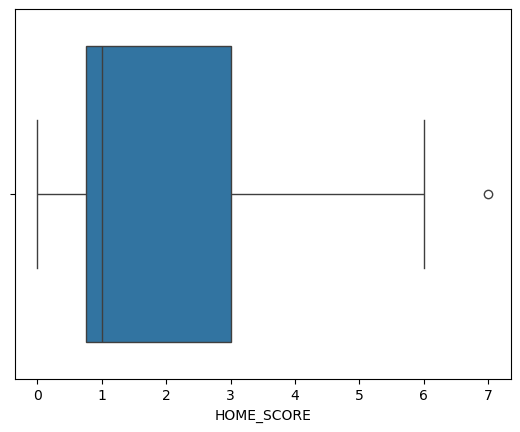

In [68]:

sns.boxplot( x= data["HOME_SCORE"].dropna())
    

<Axes: xlabel='AWAY_SCORE'>

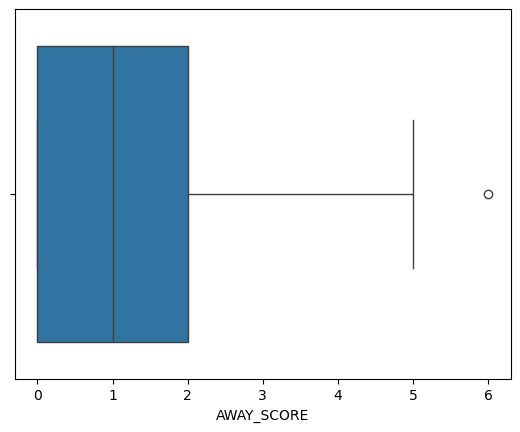

In [69]:

sns.boxplot( x= data["AWAY_SCORE"].dropna())

<Axes: xlabel='ATTENDANCE'>

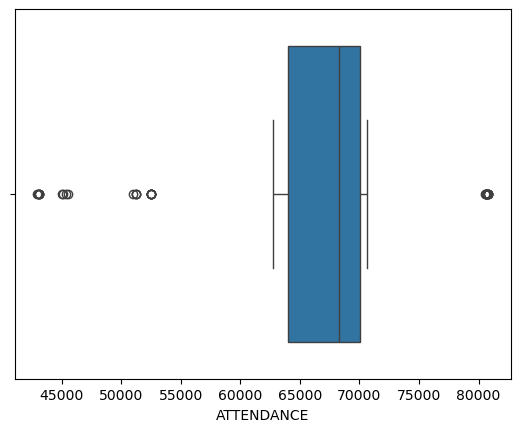

In [70]:

sns.boxplot( x= data["ATTENDANCE"].dropna())

<Axes: xlabel='HOME_TOTAL_SHOTS'>

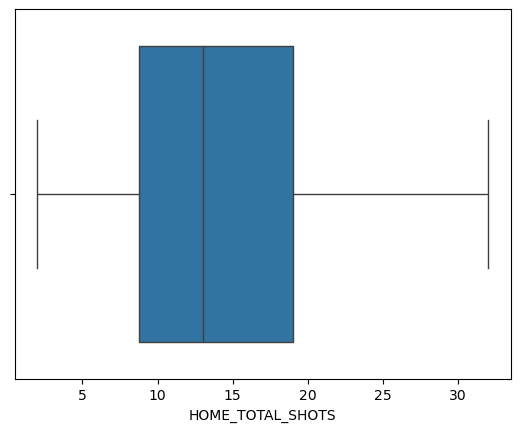

In [71]:

sns.boxplot( x= data["HOME_TOTAL_SHOTS"].dropna())

In [73]:
# Total Goals
data["TOTAL_GOALS"] = data["HOME_SCORE"] + data["AWAY_SCORE"]

In [74]:
# Goal Difference
data["GOAL_DIFFERENCE"] = abs(data["HOME_SCORE"] - data["AWAY_SCORE"])

In [75]:
# Match Result
data["MATCH_RESULT"] = data.apply(
    lambda row: "Home Win" if row["HOME_SCORE"] > row["AWAY_SCORE"]
    else ("Away Win" if row["HOME_SCORE"] < row["AWAY_SCORE"]
    else "Draw"),
    axis=1
)

In [76]:
# Total Yellow Cards
data["TOTAL_YELLOW_CARDS"] = (
    data["HOME_CARDS_YELLOW"] +
    data["AWAY_CARDS_YELLOW"]
)

In [77]:
# Total Red Cards
data["TOTAL_RED_CARDS"] = (
    data["HOME_CARDS_RED"] +
    data["AWAY_CARDS_RED"]
)

In [78]:
# Total Shots on Target
data["TOTAL_SHOTS_ON_TARGET"] = (
    data["HOME_SOT"] +
    data["AWAY_SOT"]
)

In [79]:
# Total Shots on Target
data["TOTAL_SHOTS_ON_TARGET"] = (
    data["HOME_SOT"] +
    data["AWAY_SOT"]
)

In [80]:
# Total Corners
data["TOTAL_CORNERS"] = (
    data["HOME_CORNERS"] +
    data["AWAY_CORNERS"]
)

In [81]:
# Total Saves
data["TOTAL_SAVES"] = (
    data["HOME_SAVES"] +
    data["AWAY_SAVES"]
)

In [82]:
data.head(5)

,ROUND,DAYOFWEEK,DATE,START_TIME,HOME_TEAM,AWAY_TEAM,SCORE,HOME_SCORE,AWAY_SCORE,ATTENDANCE,...,HOME_OFFSIDES,AWAY_OFFSIDES,TOTAL_GOALS,GOAL_DIFFERENCE,MATCH_RESULT,TOTAL_YELLOW_CARDS,TOTAL_RED_CARDS,TOTAL_SHOTS_ON_TARGET,TOTAL_CORNERS,TOTAL_SAVES
0,Group stage,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2,0,80824,...,1,1,2,2,Home Win,3,3,6,4,4
1,Group stage,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2,1,44985,...,2,2,3,1,Home Win,1,0,10,9,7
2,Group stage,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1,1,43002,...,1,0,2,0,Draw,5,0,7,13,3
3,Group stage,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4,1,70492,...,2,1,5,3,Home Win,6,0,7,4,3
4,Group stage,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1,1,67966,...,0,1,2,0,Draw,3,0,11,13,8


In [85]:
# Export cleaned dataset
data.to_csv("matches_cleaned.csv", index=False)
print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
